# Tutorial: Calibrating Systematic Poking Material Parameters from Reaction Forces

**Goal**: fit Systematic Poking material parameters from a set of static
reaction-force curves so that the fitted material's reactions match a
Neo-Hookean target.

## Outline

1. Build a 2×2×2 hexahedral grid;
2. Construct the elastic energy (material definition / binding / state);
3. Define load cases (uniaxial + shear) and how reactions are read;
4. Static solve: find the equilibrium with a Newton optimizer;
5. Generate "ground truth" reactions with the target material;
6. Implicit differentiation: the reaction Jacobian w.r.t. material parameters;
7. Gauss-Newton fit in log space;
8. Results and visualization.


## 0. Setup

The cell below adds the repository root to `sys.path` so `pypgo` is importable
from any directory, and sets the C++ backend's log level to `off` so spdlog
does not flood the output. Everything from here on runs silently; call
`pypgo.set_log_level("info")` at any point to turn logging back on.


In [31]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pypgo").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pypgo as pgo
import pypgo.fem as pf
import pypgo.solver as ps

# The C++ backend logs through spdlog to stdout; silence it for this notebook.
# Restore at any time with pgo.set_log_level("info").
pgo.set_log_level("info")


## 1. Experiment configuration and mesh

All experimental constants live at the top. The mesh is a unit cube split
into `GRID_SIZE^3` hexahedra (8 corners each) -- tiny, but enough to produce
meaningful reaction-force curves.

In [32]:
TARGET_E, TARGET_NU = 2.0e5, 0.35   # target Neo-Hookean material
INIT_E, INIT_NU = 1.2e5, 0.25       # starting guess for the fit
FORCE_SCALE = TARGET_E              # forces/parameters normalized by E
STATIC_TOL = 1.0e-6                 # equilibrium residual threshold
SMOOTHNESS = 1.0e-3                 # second-difference regularization weight
KNOT_COUNT = 17                     # stretch/volume knots (must be odd)
GRID_SIZE = 2                       # grid: divisions along each axis
SHEARS = (-0.8, -0.4, 0.4, 0.8)     # training shear magnitudes


def make_grid(n: int = GRID_SIZE):
    ids = np.arange((n + 1) ** 3).reshape((n + 1, n + 1, n + 1))
    vertices = np.array(
        [[i / n, j / n, k / n]
         for i in range(n + 1) for j in range(n + 1) for k in range(n + 1)],
        dtype=np.float64,
    )
    elements = np.array(
        [[ids[i, j, k], ids[i + 1, j, k], ids[i + 1, j + 1, k],
          ids[i, j + 1, k], ids[i, j, k + 1], ids[i + 1, j, k + 1],
          ids[i + 1, j + 1, k + 1], ids[i, j + 1, k + 1]]
         for i in range(n) for j in range(n) for k in range(n)],
        dtype=np.int64,
    )
    return vertices, elements


vertices, elements = make_grid()
print(f"vertices = {len(vertices)}   elements = {len(elements)}   "
      f"displacement dofs = {vertices.size}")

vertices = 27   elements = 8   displacement dofs = 81


## 2. Building the elastic energy

`pypgo`'s material system has two layers:

- **Fixed channels** (`MaterialBinding`): per-element constants such as E, nu;
- **Optimizable channels** (`MaterialState`): the values being fitted, e.g.
  Systematic Poking's f''(knot) values and lambda -- this is what the outer
  loop changes every iteration.

`make_energy(elastic, elastic_values)` combines both layers into a
`DeformationPotentialEnergy`. The target material (Neo-Hookean) has no
optimizable channels (empty array); the fitted material broadcasts the
current parameters to all elements.

In [33]:
def fixed_channel_block(elastic, num_elements):
    """Element-major fixed channels for the MaterialBinding."""
    if elastic.name == "neo_hookean":
        return np.tile([TARGET_E, TARGET_NU], (num_elements, 1))
    if elastic.name == "systematic_poking":
        # Knot locations live in the definition; no per-element fixed channels
        return np.empty((num_elements, 0), dtype=np.float64)
    raise ValueError(f"unsupported fixed channels for {elastic.name}")


def make_energy(elastic, elastic_values):
    """Build a CubicLinear deformation energy (values broadcast to all elements)."""
    volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(*make_grid()),
        pgo.mesh.volume.ENuMaterial(E=TARGET_E, nu=TARGET_NU),
    )
    mesh = pf.SimulationMesh(volume)
    plastic = pf.VolumetricPlasticityDefinition(dofs=0)

    values = np.asarray(elastic_values, dtype=np.float64).reshape(-1)
    channels = elastic.num_optimizable_channels
    if values.size == channels:
        values = np.broadcast_to(
            values.reshape(1, channels),
            (mesh.num_elements, channels),
        ).copy()
    elif values.size != mesh.num_elements * channels:
        raise ValueError("elastic_values must be constant or elementwise")

    binding = pf.MaterialBinding(
        pf.ElasticMaterialBinding(
            elastic, mesh.num_elements,
            fixed_channel_block(elastic, mesh.num_elements)),
        pf.PlasticMaterialBinding(
            plastic, mesh.num_elements,
            np.empty((mesh.num_elements, 0), dtype=np.float64)),
    )
    operator = pf.DeformationEnergyOperator(
        mesh, binding,
        formulation=pf.CubicLinear(),
        options=pf.DeformationOptions(project_hessian_psd=False),
    )
    return pf.DeformationPotentialEnergy(operator, pf.MaterialState(values, np.empty(0)))

## 3. Load cases and reactions

Each load case is a set of **displacement boundary conditions** plus a
**reaction readout**:

- Uniaxial: bottom y fixed, top y compressed to `stretch`; `confined` also
  locks the sides, `free` adds only three minimal rigid pins;
- Shear: bottom fully fixed, top x translated by `shear`.

The reaction is `reaction_selector @ gradient`, i.e. the total force on the
top face: once the equilibrium is solved, the gradient *is* the reaction force.

In [34]:
from dataclasses import dataclass


@dataclass
class LoadCase:
    label: str
    protocol: str
    coordinate: float
    fixed_dofs: np.ndarray
    fixed_values: np.ndarray
    free_dofs: np.ndarray
    reaction_selector: np.ndarray
    initial_displacement: np.ndarray
    target: float = 0.0


def constraints_from_mapping(mapping, num_dofs):
    fixed_dofs = np.array(sorted(mapping), dtype=np.int64)
    fixed_values = np.array([mapping[int(d)] for d in fixed_dofs], dtype=np.float64)
    free_dofs = np.setdiff1d(np.arange(num_dofs, dtype=np.int64), fixed_dofs)
    return fixed_dofs, fixed_values, free_dofs


def free_uniaxial_pins(vertices, bottom):
    positions = vertices[bottom]
    centroid = positions.mean(axis=0)
    d2 = ((positions[:, 0] - centroid[0]) ** 2 +
          (positions[:, 2] - centroid[2]) ** 2)
    anchor = int(bottom[np.argmin(d2)])
    same_z = bottom[np.isclose(vertices[bottom, 2], vertices[anchor, 2])]
    candidates = same_z[same_z != anchor]
    if candidates.size == 0:
        candidates = bottom[bottom != anchor]
    rotation_pin = int(candidates[np.argmax(
        np.abs(vertices[candidates, 0] - vertices[anchor, 0]))])
    return anchor, rotation_pin


def make_cases(vertices, knots):
    num_dofs = vertices.size
    bottom = np.flatnonzero(np.isclose(vertices[:, 1], 0.0))
    top = np.flatnonzero(np.isclose(vertices[:, 1], 1.0))
    cases = []
    for stretch in [k for i, k in enumerate(knots) if i != len(knots) // 2]:
        for confined in (False, True):
            mapping = {}
            for v in bottom:
                mapping[3 * int(v) + 1] = 0.0
            for v in top:
                mapping[3 * int(v) + 1] = stretch - 1.0
            if confined:
                for v in range(len(vertices)):
                    mapping[3 * v] = 0.0
                    mapping[3 * v + 2] = 0.0
            else:
                anchor, rotation_pin = free_uniaxial_pins(vertices, bottom)
                mapping[3 * anchor] = 0.0
                mapping[3 * anchor + 2] = 0.0
                mapping[3 * rotation_pin + 2] = 0.0
            fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
                mapping, num_dofs)
            selector = np.zeros(num_dofs)
            selector[3 * top + 1] = 1.0
            initial = np.zeros(num_dofs)
            initial[1::3] = (stretch - 1.0) * vertices[:, 1]
            cases.append(LoadCase(
                label=f"{'confined' if confined else 'free'}_uniaxial_{stretch:.3f}",
                protocol="confined_uniaxial" if confined else "free_uniaxial",
                coordinate=stretch,
                fixed_dofs=fixed_dofs, fixed_values=fixed_values,
                free_dofs=free_dofs, reaction_selector=selector,
                initial_displacement=initial))
    for shear in SHEARS:
        mapping = {}
        for v in bottom:
            for c in range(3):
                mapping[3 * int(v) + c] = 0.0
        for v in top:
            mapping[3 * int(v)] = shear
            mapping[3 * int(v) + 1] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top] = 1.0
        initial = np.zeros(num_dofs)
        initial[0::3] = shear * vertices[:, 1]
        cases.append(LoadCase(
            label=f"simple_shear_{shear:+.3f}", protocol="simple_shear",
            coordinate=shear,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases

## 4. Static solve

`pypgo.solver.NewtonOptimizer` now keeps all convergence tolerances inside
the termination policy. Here we use an **absolute tolerance**: the solve
converges only when $\max|\nabla E| < 10^{-10}$, so it cannot stop early
just because the initial gradient is large. The returned displacement is
therefore an exact equilibrium -- no extra polishing needed.

Let's demonstrate on a single load case and print the free residual and
reaction.


In [35]:
OPTIMIZER = ps.NewtonOptimizer(
    max_iterations=200,
    termination=ps.AbsoluteTermination(abs_tolerance=1.0e-10),
)


def solve_case(energy, case):
    problem = ps.OptimizationProblem(objective=energy)
    problem.fix_variables(
        case.fixed_dofs.tolist(), case.fixed_values,
        num_dofs=energy.num_dofs)
    x0 = case.initial_displacement.copy()
    x0[case.fixed_dofs] = case.fixed_values
    x = OPTIMIZER.solve(problem, x0).x.copy()
    if case.free_dofs.size:
        residual = np.max(np.abs(energy.gradient(x)[case.free_dofs]))
        if residual > STATIC_TOL:
            raise RuntimeError(
                f"static solve failed for {case.label}: residual={residual:.3e}")
    reaction = float(case.reaction_selector @ energy.gradient(x))
    return x, reaction


knots = np.exp(np.linspace(np.log(0.5), np.log(2.0), KNOT_COUNT))
vol_knots = np.exp(np.linspace(-1.0, 1.0, KNOT_COUNT))
initial_params = np.concatenate([
    (INIT_E / (2 * (1 + INIT_NU))) * (1 + 1 / knots ** 2),
    [INIT_E * INIT_NU / ((1 + INIT_NU) * (1 - 2 * INIT_NU))],
])
systematic = pf.SystematicPokingDefinition(
    knots, KNOT_COUNT // 2, vol_knots, KNOT_COUNT // 2)

probe = make_energy(systematic, initial_params)
probe_cases = make_cases(probe.vertex_rest_positions, knots)
x, r = solve_case(probe, probe_cases[0])
free_res = np.max(np.abs(probe.gradient(x)[probe_cases[0].free_dofs]))
print(f"case: {probe_cases[0].label}")
print(f"free residual = {free_res:.3e}   reaction / E = {r / FORCE_SCALE:.6f}")

[2026-08-06 15:43:47.546] [info] [deformationModelAssembler.cpp:154] Initializing deformation elements...
[2026-08-06 15:43:47.546] [info] [deformationModelAssembler.cpp:133] Assembler elementwise parameter channels:18,0
[2026-08-06 15:43:47.589] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=81.19 peakMiB=139.33
case: free_uniaxial_0.500
free residual = 4.185e-12   reaction / E = -0.542338
[2026-08-06 15:43:47.590] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_reduced_system_setup currentMiB=81.48 peakMiB=139.33
[2026-08-06 15:43:47.590] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_sparse_symbolic_analysis currentMiB=81.53 peakMiB=139.33
[2026-08-06 15:43:47.592] [info] [NewtonSolver.cpp:724] Newton solve time: 0.001910875


## 5. Generating the target data

We solve every load case with the target Neo-Hookean material and store the
resulting reactions as `case.target`. These are our training labels.

In [36]:
target_energy = make_energy(pf.NeoHookeanDefinition(), np.empty(0))
cases = make_cases(target_energy.vertex_rest_positions, knots)
for case in cases:
    _, case.target = solve_case(target_energy, case)

print(f"{len(cases)} training cases; first 6 normalized reactions:")
print(np.round([c.target / FORCE_SCALE for c in cases[:6]], 5))

[2026-08-06 15:43:47.617] [info] [deformationModelAssembler.cpp:154] Initializing deformation elements...
[2026-08-06 15:43:47.617] [info] [deformationModelAssembler.cpp:133] Assembler elementwise parameter channels:0,0
[2026-08-06 15:43:47.622] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=82.86 peakMiB=139.33
[2026-08-06 15:43:47.622] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_reduced_system_setup currentMiB=82.95 peakMiB=139.33
[2026-08-06 15:43:47.622] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_sparse_symbolic_analysis currentMiB=82.98 peakMiB=139.33
[2026-08-06 15:43:47.624] [info] [NewtonSolver.cpp:724] Newton solve time: 0.001100416
[2026-08-06 15:43:47.624] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=82.98 peakMiB=139.33
[2026-08-06 15:43:47.624] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton

## 6. Residual and implicit-differentiation Jacobian

The fitted parameters are $p$ (f'' spline values + lambda), optimized in
**log space**: $\theta = \log(p / E_0)$ keeps parameters positive.

The reaction $r(u(\theta))$ depends on the equilibrium displacement $u$, so
the Jacobian follows from the implicit function theorem:

$$\frac{dr}{d\theta}
= -\frac{dr}{du} K^{-1} \frac{\partial (\nabla_u E)}{\partial \theta}
+ \left.\frac{dr}{d\theta}\right|_{u\ \text{fixed}}$$

with $K = \frac{\partial^2 E}{\partial u^2}$. Both material derivatives are
evaluated with the material VJP; the adjoint
$K^{-T}\left(\frac{dr}{du}\right)^T$ is solved once per case.


In [37]:
def reaction_jacobian(energy, case, x):
    channels = energy.num_elastic_params
    hess = energy.hessian(x).to_dense()
    direct = energy.elastic_material_vjp(x, case.reaction_selector)
    direct = direct.reshape(-1, channels).sum(axis=0)
    if case.free_dofs.size:
        free = case.free_dofs
        objective_u = hess.T @ case.reaction_selector
        adjoint_free = np.linalg.solve(
            hess[np.ix_(free, free)].T, objective_u[free])
        adjoint = np.zeros(energy.num_dofs)
        adjoint[free] = adjoint_free
        direct -= energy.elastic_material_vjp(x, adjoint).reshape(-1, channels).sum(axis=0)
    return direct


def residual_and_jacobian(theta):
    parameters = FORCE_SCALE * np.exp(theta)
    energy = make_energy(systematic, parameters)
    residuals, jacobians = [], []
    for case in cases:
        x, reaction = solve_case(energy, case)
        residuals.append((reaction - case.target) / FORCE_SCALE)
        jacobians.append(
            reaction_jacobian(energy, case, x) * parameters / FORCE_SCALE)
    residual = np.asarray(residuals)
    jacobian = np.asarray(jacobians)
    if SMOOTHNESS > 0.0:
        # Second-difference regularization on f'' (lambda excluded), weighted
        # by sqrt(w) and appended as extra least-squares rows.
        stretch_count = len(theta) - 1
        operator = np.zeros((stretch_count - 2, stretch_count))
        rows = np.arange(stretch_count - 2)
        operator[rows, rows] = 1.0
        operator[rows, rows + 1] = -2.0
        operator[rows, rows + 2] = 1.0
        scale = np.sqrt(SMOOTHNESS)
        reg_jacobian = np.zeros((operator.shape[0], len(theta)))
        reg_jacobian[:, :-1] = scale * operator
        residual = np.concatenate([residual, scale * operator @ theta[:-1]])
        jacobian = np.vstack([jacobian, reg_jacobian])
    return residual, jacobian


## 7. Gauss-Newton fit

The outer loop solves the normal equations
$(J^T J + \text{damping}\,\mathrm{diag})\,\Delta\theta = -J^T r$.
If the full step does not decrease the objective, damping is increased
(Levenberg-Marquardt style) and the step is recomputed -- no line search is
needed. Every iteration re-solves all load cases and their Jacobians; that is
the main computational cost.


In [38]:
def fit_parameters(theta0, max_iterations=40):
    theta = theta0.copy()
    damping = 1.0e-5
    for iteration in range(max_iterations):
        residual, jacobian = residual_and_jacobian(theta)
        objective = 0.5 * float(residual @ residual)
        gradient = jacobian.T @ residual
        train_rmse = np.sqrt(np.mean(residual[:len(cases)] ** 2))
        print(f"iter {iteration:2d}  objective={objective:.3e}  "
              f"train_rmse={train_rmse:.3e}")
        if np.linalg.norm(gradient, ord=np.inf) < 1.0e-9:
            print("converged: gradient below tolerance")
            break
        normal = jacobian.T @ jacobian
        diagonal = np.maximum(np.diag(normal), 1.0e-12)
        for _ in range(12):
            step = np.linalg.solve(
                normal + damping * np.diag(diagonal), -gradient)
            if np.max(np.abs(step)) > 0.75:
                step *= 0.75 / np.max(np.abs(step))
            candidate = theta + step
            candidate_residual, _ = residual_and_jacobian(candidate)
            candidate_objective = 0.5 * float(
                candidate_residual @ candidate_residual)
            if candidate_objective < objective:
                theta = candidate
                damping = max(damping / 3.0, 1.0e-12)
                break
            damping *= 10.0
        else:
            print("stopping: no decreasing step found")
            break
    return theta


theta0 = np.log(initial_params / FORCE_SCALE)
theta = fit_parameters(theta0)


[2026-08-06 15:43:47.757] [info] [deformationModelAssembler.cpp:154] Initializing deformation elements...
[2026-08-06 15:43:47.757] [info] [deformationModelAssembler.cpp:133] Assembler elementwise parameter channels:18,0
[2026-08-06 15:43:47.757] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=84.64 peakMiB=139.33
[2026-08-06 15:43:47.757] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_reduced_system_setup currentMiB=84.75 peakMiB=139.33
[2026-08-06 15:43:47.757] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_sparse_symbolic_analysis currentMiB=84.78 peakMiB=139.33
[2026-08-06 15:43:47.759] [info] [NewtonSolver.cpp:724] Newton solve time: 0.001073084
[2026-08-06 15:43:47.762] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=85.23 peakMiB=139.33
[2026-08-06 15:43:47.762] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newto

## 8. Results and visualization

After the fit we check two things: how much the training RMSE dropped, and
how close the fitted f''/lambda values are to the closed-form Neo-Hookean
reference. Then we plot a few reaction curves to visually confirm that the
fitted material's reactions match the target.

In [39]:
fitted = FORCE_SCALE * np.exp(theta)
mu, lam = (TARGET_E / (2 * (1 + TARGET_NU)),
           TARGET_E * TARGET_NU / ((1 + TARGET_NU) * (1 - 2 * TARGET_NU)))
reference = np.concatenate([mu * (1 + 1 / knots ** 2), [lam]])

res_final, _ = residual_and_jacobian(theta)
final_rmse = np.sqrt(np.mean(res_final[:len(cases)] ** 2))
print(f"train RMSE: initial=0.341  fitted={final_rmse:.6e}")
print(f"{'parameter':10s} {'fitted':>12s} {'reference':>12s}")
for i, name in enumerate([f"f_dd_{i}" for i in range(KNOT_COUNT)] + ["lambda"]):
    print(f"{name:10s} {fitted[i]:12.1f} {reference[i]:12.1f}")

[2026-08-06 15:43:48.711] [info] [deformationModelAssembler.cpp:154] Initializing deformation elements...
[2026-08-06 15:43:48.711] [info] [deformationModelAssembler.cpp:133] Assembler elementwise parameter channels:18,0
[2026-08-06 15:43:48.713] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=88.62 peakMiB=139.33
[2026-08-06 15:43:48.713] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_reduced_system_setup currentMiB=88.62 peakMiB=139.33
[2026-08-06 15:43:48.713] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_sparse_symbolic_analysis currentMiB=88.62 peakMiB=139.33
[2026-08-06 15:43:48.714] [info] [NewtonSolver.cpp:724] Newton solve time: 0.001366417
[2026-08-06 15:43:48.717] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=88.62 peakMiB=139.33
[2026-08-06 15:43:48.717] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newto

[2026-08-06 15:43:48.842] [info] [deformationModelAssembler.cpp:154] Initializing deformation elements...
[2026-08-06 15:43:48.842] [info] [deformationModelAssembler.cpp:133] Assembler elementwise parameter channels:18,0
[2026-08-06 15:43:48.843] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=89.48 peakMiB=139.33
[2026-08-06 15:43:48.843] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_reduced_system_setup currentMiB=89.48 peakMiB=139.33
[2026-08-06 15:43:48.843] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_sparse_symbolic_analysis currentMiB=89.48 peakMiB=139.33
[2026-08-06 15:43:48.846] [info] [NewtonSolver.cpp:724] Newton solve time: 0.00227525
[2026-08-06 15:43:48.846] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton.after_full_hessian currentMiB=89.48 peakMiB=139.33
[2026-08-06 15:43:48.846] [info] [NewtonSolver.cpp:34] Process memory checkpoint stage=newton

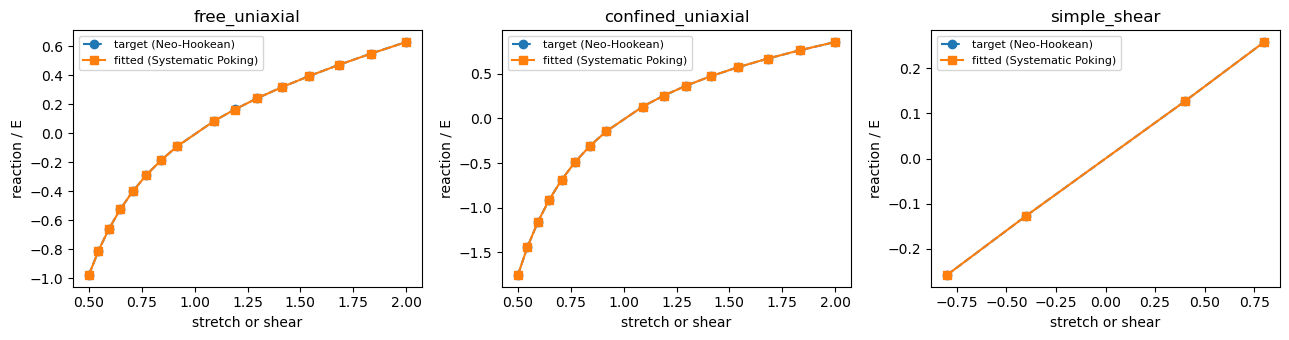

In [40]:
fitted_energy = make_energy(systematic, fitted)
predicted = np.asarray([solve_case(fitted_energy, c)[1] for c in cases])

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, protocol in zip(
            axes, ("free_uniaxial", "confined_uniaxial", "simple_shear")):
        sel = np.array([i for i, c in enumerate(cases) if c.protocol == protocol])
        order = np.argsort([cases[i].coordinate for i in sel])
        sel = sel[order]
        x_plot = [cases[i].coordinate for i in sel]
        ax.plot(x_plot, [cases[i].target / FORCE_SCALE for i in sel],
                "o--", label="target (Neo-Hookean)")
        ax.plot(x_plot, [predicted[i] / FORCE_SCALE for i in sel],
                "s-", label="fitted (Systematic Poking)")
        ax.set_title(protocol)
        ax.set_xlabel("stretch or shear")
        ax.set_ylabel("reaction / E")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the plot")